# Week 3 Workshop Notebook: Conditional Probability, Bayes' Theorem, and Probabilistic Classification

## Context: Nepal Tourism Bookings

This notebook uses the same clean synthetic Nepal tourism dataset from Week 2. This week, the focus is not correlation or multicollinearity. The focus is **probability and uncertainty**.

You will work with the target variable:

$$
Y = \text{HighValueBooking}
$$

where:

$$
Y=1 \quad \text{means HighValueBooking = Yes}
$$

and:

$$
Y=0 \quad \text{means HighValueBooking = No}
$$

## Your mission
By the end of this notebook, you should be able to explain:

1. What a base rate or prior probability means.
2. How conditional probability changes interpretation.
3. How Bayes' Theorem updates prior belief using evidence.
4. How Naive Bayes makes probabilistic predictions.
5. How changing priors and decision thresholds can change model decisions.

Complete the markdown answer cells as you go. Export your final notebook as HTML or PDF for submission.

## Key formulas for this week

### Conditional probability

$$
P(A\mid B)=\frac{P(A\cap B)}{P(B)}
$$

### Bayes' Theorem

$$
P(Y\mid X)=\frac{P(X\mid Y)P(Y)}{P(X)}
$$

### Naive Bayes

$$
P(Y=y\mid X=x)\propto P(Y=y)\prod_{j=1}^{p}P(X_j=x_j\mid Y=y)
$$

### Decision rule

$$
\hat{Y}=1 \quad \text{if} \quad P(Y=1\mid X)\geq \tau
$$

where:

$$
\tau = \text{decision threshold}
$$

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

DATA_PATH = "Nepal_Tourism_Bayesian_Workshop_Dataset.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,BookingID,BookingMonth,Season,RouteName,Region,MarketSegment,Travelers,LeadDays,TripDays,MaxAltitudeM,DifficultyScore,PermitComplexityScore,AcclimatizationDays,GuideIncluded,AccommodationLevel,BookingChannel,SpendPerPersonUSD,TotalSpendUSD,SatisfactionScore,RebookIntentScore,HighValueBooking,HighSatisfaction
0,NPTRK10001,4,Spring,Annapurna Circuit,Annapurna,International,2,89,15,5416,5,3,4,Yes,Budget,Online Platform,1431.0,2804.0,3.9,3.5,No,No
1,NPTRK10002,12,Winter,Annapurna Base Camp,Annapurna,SAARC,6,47,8,4130,3,2,1,Yes,Standard,Direct,749.0,4435.0,4.6,4.9,No,Yes
2,NPTRK10003,10,Autumn,Kathmandu-Pokhara Heritage,City & Culture,SAARC,5,39,6,1400,1,1,0,No,Comfort,Direct,777.0,3910.0,4.9,4.6,No,Yes
3,NPTRK10004,8,Monsoon,Upper Mustang,Mustang,International,3,73,14,3840,4,5,1,Yes,Comfort,Direct,3327.0,9945.0,4.2,4.0,Yes,No
4,NPTRK10005,10,Autumn,Upper Mustang,Mustang,International,2,102,13,3840,4,5,1,Yes,Standard,Travel Agent,2792.0,5392.0,4.2,3.9,Yes,No


In [2]:
# Dataset size and structure
print("Rows and columns:", df.shape)
df.info()

Rows and columns: (260, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BookingID              260 non-null    object 
 1   BookingMonth           260 non-null    int64  
 2   Season                 260 non-null    object 
 3   RouteName              260 non-null    object 
 4   Region                 260 non-null    object 
 5   MarketSegment          260 non-null    object 
 6   Travelers              260 non-null    int64  
 7   LeadDays               260 non-null    int64  
 8   TripDays               260 non-null    int64  
 9   MaxAltitudeM           260 non-null    int64  
 10  DifficultyScore        260 non-null    int64  
 11  PermitComplexityScore  260 non-null    int64  
 12  AcclimatizationDays    260 non-null    int64  
 13  GuideIncluded          260 non-null    object 
 14  AccommodationLevel     260 non

---
# Part 1: Base Rate and Prior Probability

Before seeing any booking details, the model has a starting belief about whether a booking is high-value.

This is called the **base rate** or **prior probability**.

$$
P(Y=1)=P(\text{HighValueBooking=Yes})
$$

In [3]:
# Encode target variable
# Yes = 1, No = 0

df["HighValueBinary"] = df["HighValueBooking"].map({"Yes": 1, "No": 0})

class_counts = df["HighValueBooking"].value_counts()
class_props = df["HighValueBooking"].value_counts(normalize=True)

print("Class counts:")
print(class_counts)

print("\nClass proportions:")
print(class_props.round(3))

Class counts:
HighValueBooking
No     195
Yes     65
Name: count, dtype: int64

Class proportions:
HighValueBooking
No     0.75
Yes    0.25
Name: proportion, dtype: float64


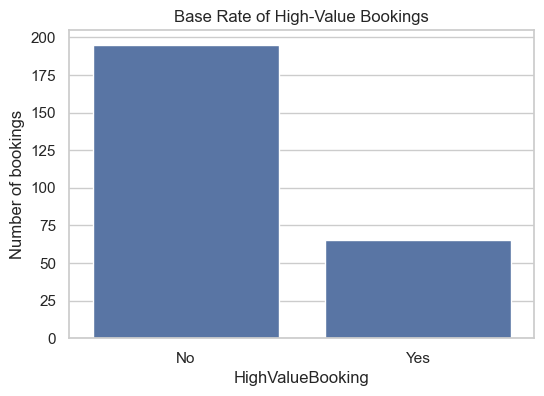

In [4]:
# Visualize the prior / base rate
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="HighValueBooking", order=["No", "Yes"])
plt.title("Base Rate of High-Value Bookings")
plt.xlabel("HighValueBooking")
plt.ylabel("Number of bookings")
plt.show()

## Question 1: Prior probability

Use the output above to answer:

1. What is the prior probability of a high-value booking?
2. Is the target class balanced or imbalanced?
3. Why does this base rate matter for machine learning?

### Your answer

1. The prior probability of a high-value booking is 0.25 (or 25%).
2. The target class is imbalanced because 75% are No and only 25% are Yes.
3. This base rate matters because if a model always predicts 'No', it will still get 75% accuracy. We need to be careful with metrics like accuracy.


---
# Part 2: Conditional Probability

Conditional probability asks:

$$
P(A\mid B)
$$

This means:

> What is the probability of event A, given that event B is already known?

Tourism example:

$$
P(\text{HighValue} \mid \text{International})
$$

This asks:

> Among international bookings, what proportion are high-value?

In [5]:
# Conditional probability table: HighValueBooking by MarketSegment
ct_market = pd.crosstab(df["MarketSegment"], df["HighValueBooking"], margins=True)
ct_market

HighValueBooking,No,Yes,All
MarketSegment,,,
Domestic,49,12,61
International,103,40,143
SAARC,43,13,56
All,195,65,260


In [6]:
# Row-normalized table: P(HighValueBooking | MarketSegment)
cond_market = pd.crosstab(df["MarketSegment"], df["HighValueBooking"], normalize="index")
round(cond_market, 3)

HighValueBooking,No,Yes
MarketSegment,,
Domestic,0.803,0.197
International,0.720,0.280
SAARC,0.768,0.232


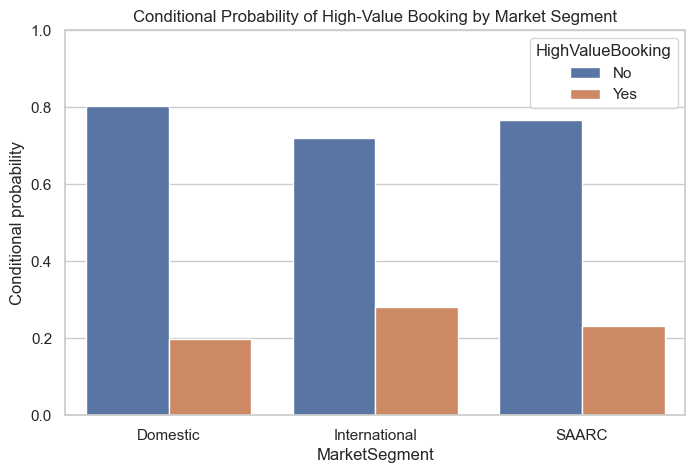

In [7]:
# Visualize conditional probability by MarketSegment
cond_plot = cond_market.reset_index().melt(id_vars="MarketSegment", var_name="HighValueBooking", value_name="Probability")

plt.figure(figsize=(8,5))
sns.barplot(data=cond_plot, x="MarketSegment", y="Probability", hue="HighValueBooking")
plt.title("Conditional Probability of High-Value Booking by Market Segment")
plt.ylabel("Conditional probability")
plt.ylim(0, 1)
plt.show()

## Numerical Exercise 1: Calculate a conditional probability manually

Using the table above, calculate:

$$
P(\text{HighValue}=\text{Yes}\mid \text{MarketSegment}=\text{International})
$$

Use:

$$
P(A\mid B)=\frac{\text{Number of cases where A and B both happen}}{\text{Number of cases where B happens}}
$$

### Your working

Numerator: 40

Denominator: 143

Final probability: 40 / 143 = 0.2797 (or 28.0%)

### Your interpretation

The probability that an international tourist makes a high-value booking is about 28%, which is slightly higher than the overall base rate of 25%.


In [8]:
# Conditional probability of high-value booking by accommodation level
cond_acc = pd.crosstab(df["AccommodationLevel"], df["HighValueBooking"], normalize="index")
round(cond_acc, 3)

HighValueBooking,No,Yes
AccommodationLevel,,
Budget,0.841,0.159
Comfort,0.646,0.354
Standard,0.758,0.242


In [9]:
# Conditional probability of high-value booking by guide inclusion
cond_guide = pd.crosstab(df["GuideIncluded"], df["HighValueBooking"], normalize="index")
round(cond_guide, 3)

HighValueBooking,No,Yes
GuideIncluded,,
No,0.974,0.026
Yes,0.710,0.290


## Question 2: Conditional probability interpretation

Compare the conditional probability of high-value booking across:

- Market segment
- Accommodation level
- Guide inclusion

Which condition seems most strongly associated with high-value booking?

Important: does this prove causation? Why or why not?

### Your answer

Comfort accommodation (35.4%) and having a guide included (29%) are most strongly associated with high-value bookings. Especially having no guide has a very low rate (2.6%).

No, this does not prove causation. It could be that richer tourists just choose comfort packages and guides, rather than the guide itself causing the high spending.


---
# Part 3: Bayes' Theorem

Bayes' Theorem updates prior probability using evidence.

$$
P(Y\mid X)=\frac{P(X\mid Y)P(Y)}{P(X)}
$$

For example:

$$
P(\text{HighValue}\mid \text{International})
=
\frac{P(\text{International}\mid \text{HighValue})P(\text{HighValue})}{P(\text{International})}
$$

This section compares two ways of getting the same answer:

1. Direct conditional probability from a row-normalized table.
2. Bayes' Theorem using prior, likelihood, and evidence.

In [10]:
# Compute Bayes' theorem components for: P(HighValue = Yes | MarketSegment = International)

A = df["HighValueBooking"] == "Yes"
B = df["MarketSegment"] == "International"

prior_high = A.mean()                               # P(HighValue)
likelihood_international_given_high = B[A].mean()   # P(International | HighValue)
evidence_international = B.mean()                   # P(International)
posterior_bayes = (likelihood_international_given_high * prior_high) / evidence_international
posterior_direct = A[B].mean()                      # P(HighValue | International)

print("P(HighValue):", round(prior_high, 4))
print("P(International | HighValue):", round(likelihood_international_given_high, 4))
print("P(International):", round(evidence_international, 4))
print("Bayes posterior P(HighValue | International):", round(posterior_bayes, 4))
print("Direct conditional P(HighValue | International):", round(posterior_direct, 4))

P(HighValue): 0.25
P(International | HighValue): 0.6154
P(International): 0.55
Bayes posterior P(HighValue | International): 0.2797
Direct conditional P(HighValue | International): 0.2797


## Numerical Exercise 2: Bayes' Theorem

Fill in the values from the output above:

$$
P(\text{HighValue})=0.25
$$

$$
P(\text{International}\mid \text{HighValue})=0.6154
$$

$$
P(\text{International})=0.55
$$

Now compute:

$$
P(\text{HighValue}\mid \text{International})
=
\frac{P(\text{International}\mid \text{HighValue})P(\text{HighValue})}{P(\text{International})}
$$

### Your working

P(HighValue) = 0.25
P(International | HighValue) = 0.6154
P(International) = 0.55
Posterior = (0.6154 * 0.25) / 0.55 = 0.15385 / 0.55 = 0.2797

### Interpretation

What changed from the prior probability to the posterior probability after knowing that the customer is international?

The probability of a high-value booking increased from the prior of 25% to a posterior of 27.97% after we learned that the customer is international. Knowing they are international makes them slightly more likely to make a high-value booking.


---
# Part 4: Naive Bayes Classifier

Naive Bayes is a probabilistic classifier based on Bayes' Theorem.

It estimates:

$$
P(Y\mid X_1,X_2,\ldots,X_p)
$$

For high-value booking prediction, this means:

$$
P(\text{HighValue}\mid \text{MarketSegment, TripLength, Accommodation, Guide, Season})
$$

The model uses:

$$
P(Y=y\mid X=x)\propto P(Y=y)\prod_{j=1}^{p}P(X_j=x_j\mid Y=y)
$$

We will use a categorical Naive Bayes model by converting selected numerical variables into categories.

In [11]:
# Create simple categories for Naive Bayes
nb_df = df.copy()

nb_df["TripLengthCategory"] = pd.cut(
    nb_df["TripDays"],
    bins=[0, 6, 10, 20],
    labels=["Short", "Medium", "Long"],
    include_lowest=True
)

nb_df["LeadTimeCategory"] = pd.cut(
    nb_df["LeadDays"],
    bins=[0, 30, 70, 200],
    labels=["ShortLead", "MediumLead", "LongLead"],
    include_lowest=True
)

nb_df["DifficultyCategory"] = pd.cut(
    nb_df["DifficultyScore"],
    bins=[0, 2, 3, 5],
    labels=["Easy", "Moderate", "Difficult"],
    include_lowest=True
)

features = [
    "MarketSegment", "TripLengthCategory", "LeadTimeCategory",
    "AccommodationLevel", "GuideIncluded", "Season", "DifficultyCategory"
]

target = "HighValueBooking"

nb_df[features + [target]].head()

,MarketSegment,TripLengthCategory,LeadTimeCategory,AccommodationLevel,GuideIncluded,Season,DifficultyCategory,HighValueBooking
0,International,Long,LongLead,Budget,Yes,Spring,Difficult,No
1,SAARC,Medium,MediumLead,Standard,Yes,Winter,Moderate,No
2,SAARC,Short,MediumLead,Comfort,No,Autumn,Easy,No
3,International,Long,LongLead,Comfort,Yes,Monsoon,Difficult,Yes
4,International,Long,LongLead,Standard,Yes,Autumn,Difficult,Yes


In [12]:
# Encode categorical variables and fit a Categorical Naive Bayes model
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = nb_df[features]
y = nb_df[target]

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class order:", list(label_encoder.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

model = CategoricalNB()
model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification report:")
print(classification_report(y_test, pred, target_names=label_encoder.classes_))

Class order: ['No', 'Yes']
Accuracy: 0.738

Confusion matrix:
[[39 10]
 [ 7  9]]

Classification report:
              precision    recall  f1-score   support

          No       0.85      0.80      0.82        49
         Yes       0.47      0.56      0.51        16

    accuracy                           0.74        65
   macro avg       0.66      0.68      0.67        65
weighted avg       0.76      0.74      0.75        65



## Question 3: Naive Bayes output

Look at the confusion matrix and classification report.

1. Is the model better at identifying `No` or `Yes` high-value bookings?
2. Why might class imbalance affect this result?
3. Why should accuracy not be the only metric?

### Your answer

1. The model is better at identifying 'No' bookings. It has higher precision (85% vs 47%) and recall (80% vs 56%) for 'No'.
2. The dataset has way more 'No' bookings (75%), so the model learns the patterns of 'No' bookings much better than 'Yes'.
3. If we only look at accuracy, a model that predicts 'No' for everything gets 75% accuracy but is useless. Precision and recall help us see how well it finds actual high-value bookings.


In [13]:
# Predict probability for one fixed booking profile
fixed_profile = pd.DataFrame([{
    "MarketSegment": "International",
    "TripLengthCategory": "Long",
    "LeadTimeCategory": "LongLead",
    "AccommodationLevel": "Comfort",
    "GuideIncluded": "Yes",
    "Season": "Autumn",
    "DifficultyCategory": "Difficult"
}])

fixed_encoded = encoder.transform(fixed_profile)
base_proba = model.predict_proba(fixed_encoded)[0]

prob_table = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Predicted probability": base_proba
})
prob_table

,Class,Predicted probability
0,No,0.08197
1,Yes,0.91803


## Numerical Exercise 3: Interpreting posterior probabilities

For the fixed profile:

- International customer
- Long trip
- Long lead time
- Comfort accommodation
- Guide included
- Autumn season
- Difficult route

Record the model's posterior probability:

$$
P(\text{HighValue}=\text{Yes}\mid X)=0.91803
$$

At threshold:

$$
\tau=0.5
$$

what is the predicted class?

### Your answer

The predicted class is 'Yes' because 0.91803 is greater than the 0.5 threshold.


---
# Part 5: Changing Priors

Now we will use the same booking profile but change the class prior.

This demonstrates the lecture idea:

$$
\text{Same evidence}+\text{different prior}\rightarrow \text{different posterior}
$$

In `CategoricalNB`, we can set class priors manually.

Class order is printed above. Usually it is:

$$
[\text{No}, \text{Yes}]
$$

In [14]:
# Fit Naive Bayes models with different priors
# IMPORTANT: class order is label_encoder.classes_ ; usually ['No', 'Yes']

prior_scenarios = {
    "Normal dataset prior": None,
    "Low high-value prior: P(Yes)=0.15": [0.85, 0.15],
    "Balanced prior: P(Yes)=0.50": [0.50, 0.50],
    "Luxury campaign prior: P(Yes)=0.45": [0.55, 0.45]
}

rows = []
for scenario, priors in prior_scenarios.items():
    if priors is None:
        m = CategoricalNB()
    else:
        m = CategoricalNB(class_prior=np.array(priors))
    m.fit(X_train, y_train)
    p = m.predict_proba(fixed_encoded)[0]
    rows.append({
        "Scenario": scenario,
        "P(No | X)": p[0],
        "P(Yes | X)": p[1],
        "Predicted class at threshold 0.5": "Yes" if p[1] >= 0.5 else "No"
    })

prior_result = pd.DataFrame(rows)
prior_result

,Scenario,P(No | X),P(Yes | X),Predicted class at threshold 0.5
0,Normal dataset prior,0.081970,0.918030,Yes
1,Low high-value prior: P(Yes)=0.15,0.145162,0.854838,Yes
2,Balanced prior: P(Yes)=0.50,0.029095,0.970905,Yes
3,Luxury campaign prior: P(Yes)=0.45,0.035332,0.964668,Yes


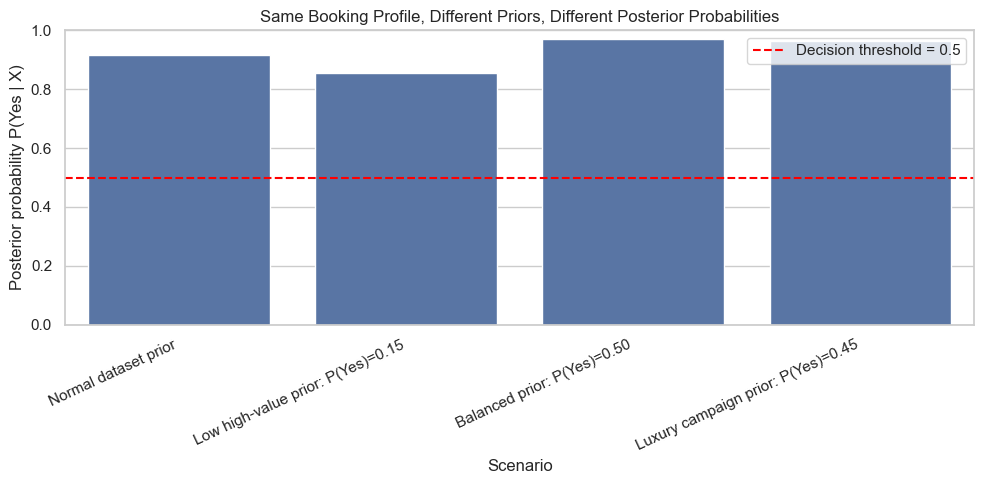

In [15]:
# Visualize posterior probability of HighValue=Yes under different priors
plt.figure(figsize=(10,5))
sns.barplot(data=prior_result, x="Scenario", y="P(Yes | X)")
plt.axhline(0.5, color="red", linestyle="--", label="Decision threshold = 0.5")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.ylabel("Posterior probability P(Yes | X)")
plt.title("Same Booking Profile, Different Priors, Different Posterior Probabilities")
plt.legend()
plt.tight_layout()
plt.show()

## Question 4: Prior shift interpretation

Using the prior scenario table and bar chart:

1. What happened to the posterior probability when the high-value prior increased?
2. Did the customer profile change?
3. Why can the model decision change even when the evidence is the same?
4. Connect your answer to this formula:

$$
\frac{P(Y=1\mid X)}{P(Y=0\mid X)}
=
\frac{P(X\mid Y=1)}{P(X\mid Y=0)}
\times
\frac{P(Y=1)}{P(Y=0)}
$$

### Your answer

1. When the high-value prior increased, the posterior probability P(Yes | X) also increased.
2. No, the customer profile did not change at all.
3. The model decision can change because the posterior probability is calculated by multiplying the evidence (likelihood) by the prior. A higher prior starts with a higher probability, which increases the final posterior.
4. In the formula, the posterior ratio is the likelihood ratio multiplied by the prior ratio. If the prior ratio P(Y=1)/P(Y=0) goes up, the posterior ratio goes up even if the likelihood ratio is constant.


---
# Part 6: Decision Thresholds

A probability is not the final decision. A threshold converts probability into a class.

$$
\hat{Y}=1 \quad \text{if} \quad P(Y=1\mid X)\geq \tau
$$

We will now keep the same model probabilities but change the threshold.

In [16]:
# Use probabilities from the default model on all test cases
p_yes = proba[:, list(label_encoder.classes_).index("Yes")]

thresholds = [0.30, 0.50, 0.70]
threshold_results = []
for t in thresholds:
    pred_t = (p_yes >= t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "Predicted Yes count": int(pred_t.sum()),
        "Predicted No count": int(len(pred_t) - pred_t.sum()),
        "Accuracy": accuracy_score(y_test, pred_t)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Predicted Yes count,Predicted No count,Accuracy
0,0.3,21,44,0.738462
1,0.5,19,46,0.738462
2,0.7,14,51,0.753846


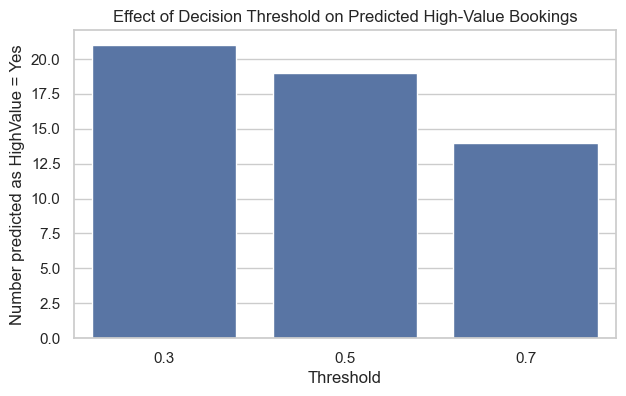

In [17]:
# Visualize how threshold changes the number of predicted high-value bookings
plt.figure(figsize=(7,4))
sns.barplot(data=threshold_df, x="Threshold", y="Predicted Yes count")
plt.title("Effect of Decision Threshold on Predicted High-Value Bookings")
plt.ylabel("Number predicted as HighValue = Yes")
plt.show()

## Question 5: Threshold interpretation

1. What happens to the number of predicted high-value bookings when the threshold decreases?
2. What happens when the threshold increases?
3. In tourism marketing, when might a lower threshold make sense?
4. When might a higher threshold make sense?

### Your answer

1. When the threshold decreases, the number of predicted high-value bookings increases.
2. When the threshold increases, the number of predicted high-value bookings decreases.
3. A lower threshold is good when sending marketing emails is cheap and we want to target as many potential high-value customers as possible.
4. A higher threshold makes sense when we offer expensive perks (like free gifts) and want to be very sure the customer is high-value.


---
# Part 7: Simple Decision Boundary Demonstration

This section uses only one feature:

$$
X=\text{TripDays}
$$

The goal is to show that changing the prior can move a decision boundary.

This is a simplified demonstration, not a full production model.

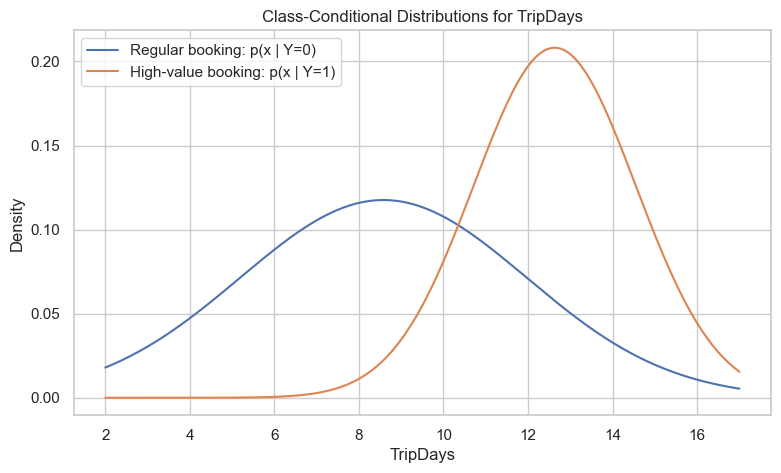

Regular bookings: mean TripDays = 8.58 SD = 3.39
High-value bookings: mean TripDays = 12.63 SD = 1.92


In [18]:
# One-dimensional Gaussian likelihood demonstration using TripDays
from scipy.stats import norm

x = np.linspace(df["TripDays"].min()-1, df["TripDays"].max()+1, 300)

trip_yes = df.loc[df["HighValueBooking"] == "Yes", "TripDays"]
trip_no = df.loc[df["HighValueBooking"] == "No", "TripDays"]

mu_yes, sd_yes = trip_yes.mean(), trip_yes.std()
mu_no, sd_no = trip_no.mean(), trip_no.std()

pdf_yes = norm.pdf(x, mu_yes, sd_yes)
pdf_no = norm.pdf(x, mu_no, sd_no)

plt.figure(figsize=(9,5))
plt.plot(x, pdf_no, label="Regular booking: p(x | Y=0)")
plt.plot(x, pdf_yes, label="High-value booking: p(x | Y=1)")
plt.xlabel("TripDays")
plt.ylabel("Density")
plt.title("Class-Conditional Distributions for TripDays")
plt.legend()
plt.show()

print("Regular bookings: mean TripDays =", round(mu_no,2), "SD =", round(sd_no,2))
print("High-value bookings: mean TripDays =", round(mu_yes,2), "SD =", round(sd_yes,2))

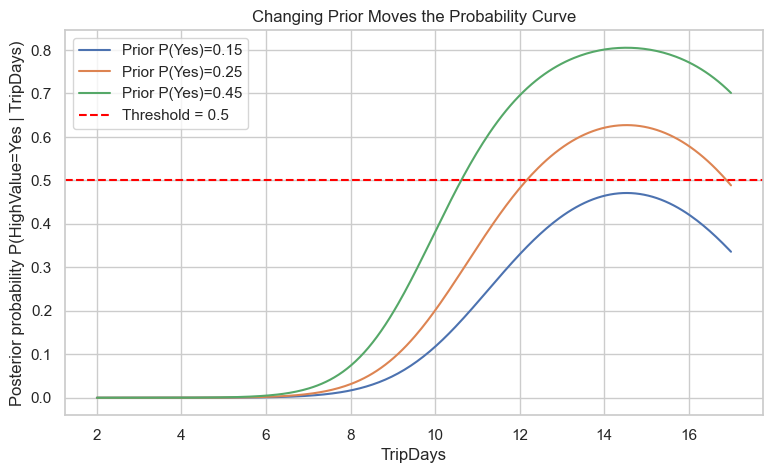

In [19]:
# Compute posterior P(Y=1 | TripDays=x) for different priors

def posterior_yes_given_tripdays(x_values, prior_yes):
    prior_no = 1 - prior_yes
    likelihood_yes = norm.pdf(x_values, mu_yes, sd_yes)
    likelihood_no = norm.pdf(x_values, mu_no, sd_no)
    numerator = likelihood_yes * prior_yes
    denominator = numerator + likelihood_no * prior_no
    return numerator / denominator

priors = [0.15, 0.25, 0.45]
plt.figure(figsize=(9,5))
for py in priors:
    post = posterior_yes_given_tripdays(x, py)
    plt.plot(x, post, label=f"Prior P(Yes)={py}")

plt.axhline(0.5, color="red", linestyle="--", label="Threshold = 0.5")
plt.xlabel("TripDays")
plt.ylabel("Posterior probability P(HighValue=Yes | TripDays)")
plt.title("Changing Prior Moves the Probability Curve")
plt.legend()
plt.show()

In [20]:
# Approximate decision boundary for each prior: first TripDays where posterior crosses 0.5
boundaries = []
for py in priors:
    post = posterior_yes_given_tripdays(x, py)
    above = np.where(post >= 0.5)[0]
    boundary = x[above[0]] if len(above) > 0 else np.nan
    boundaries.append({"Prior P(Yes)": py, "Approx boundary TripDays where posterior >= 0.5": boundary})

pd.DataFrame(boundaries)

,Prior P(Yes),Approx boundary TripDays where posterior >= 0.5
0,0.15,NaN
1,0.25,12.183946
2,0.45,10.628763


## Question 6: Decision boundary movement

Look at the probability curves and the boundary table.

1. What happens to the TripDays boundary when the prior probability of high-value booking increases?
2. Why does this happen?
3. How does this connect to the lecture idea that decision boundaries can shift even when class-conditional distributions stay the same?

### Your answer

1. When the prior probability of high-value booking increases, the TripDays boundary decreases .
2. This happens because a higher prior means we start with a higher baseline probability, so we need less evidence (fewer trip days) to decide it is high-value.
3. This shows that the decision boundary depends on both the feature distribution and the class priors. If priors change, the boundary shifts even if the feature distribution stays the same.


---
# Final Task: Short Interpretation Memo

Write a short memo of **250 to 350 words** to the tourism company.

Your memo should explain:

1. The base rate of high-value bookings.
2. One important conditional probability finding.
3. How Bayes' Theorem updates prior probability using evidence.
4. How the Naive Bayes model produced posterior probabilities.
5. Why changing priors or thresholds can change model decisions.
6. One warning about using model probabilities in real deployment.

## Your memo

Dear Tourism Company,

We have finished analyzing the tourism booking data and here is a simple memo.

First, the base rate (prior probability) of high-value bookings is 25%. This means only 1 out of 4 bookings is high-value. This is the starting point before we know anything about a customer.

Second, we found some interesting conditional probabilities. Customers who book comfort accommodation have a 35.4% chance of being high-value, and customers who include a guide have a 29% chance of being high-value. But customers who do not include a guide have only a 2.6% chance of being high-value.

Third, Bayes' Theorem helps us update our starting probability when we get new information. For example, if we know the customer is international, the chance of a high-value booking goes up from 25% to 28%. Our Naive Bayes model uses this logic to combine many features (like season, guide, and trip days) to find the final probability for each customer.

Fourth, we can change how the model decides by changing priors or thresholds. If we increase the prior (like during a luxury marketing campaign), the model will predict more high-value bookings because it starts with a higher probability. Also, if we lower the decision threshold from 0.5 to 0.3, the model will predict more high-value bookings. This is good if we want to target more customers with cheap emails.

Finally, a warning: the Naive Bayes model assumes that all features are independent. But features like trip length and guide inclusion are often related. This means the model's probabilities might be too confident when we use it in real life. We should use them carefully.

Sincerely,
Data Science Team
